Under the Black-Scholes hedging argument we now that the FD PDE is given by:
$$ \partial_t C_d(t,x) + 0.5 \sigma^2s^2\partial_{ss}C_d(t,s)+rs\partial_sC_d(t,s) - r C_d(t,s) = 0,
$$
with the terminal condition
$$ C_d(T,s) = 1\{s \geq K\}.
$$

Now we will find the solution under this PDE, under the risk-neutral pricing we know that
$$
C_d(t, x) = e^{-r(T-t)}\mathbb{E}^{\mathcal{Q}}[1_{S_T \geq K}|S_t = x],
$$
expectation of an indicator function equals the probability so,
$$
C_d(t, x) = e^{-r(T-t)}\mathbb{Q}(S_T \geq K|S_t=x).
$$
As seen in the lecture the price process $S_t$ can be rewritten by taking the log, and applying Ito's lemma to;
$$
ln(S_T) = ln(S_t)+(r-0.5\sigma^2)(T-t) + \sigma(B_T-B_t)
$$
Note that $\sigma(B_T-B_t) \sim N(0, \sigma^2(T-t))$ since $B_t$ is a brownian motion. So
$$
ln(S_T) \sim N(ln(S_t)+(r-0.5\sigma^2)(T-t), \sigma^2(T-t)).
$$
Denote $\mu = ln(S_t)+(r-0.5\sigma^2)(T-t) $ and define $Z= \frac{ln(S_t)-\mu}{\sigma(\sqrt{T-t})},$ so $Z\sim N(0,1).$

Know we can rewrite $C_d(t,x)$ using the log transformation into
$$
C_d(t, x) = e^{-r(T-t)}\mathbb{Q}(ln(S_T) \geq ln(K)|S_t=x)
$$
which equals
$$
C_d(t, x) = e^{-r(T-t)}\mathbb{Q}(Z\geq \frac{ln(K)-\mu}{\sigma(\sqrt{T-t})} )
$$
which we can, using the earlier found distribution, rewrite into the desired form,
$$
C_d(t,x) = e^{-r(T-t)}\Phi(\frac{ln(x/K)+(r-\sigma^2/2)(T-t)}{|\sigma|\sqrt{T-t}})
$$

### Monte Carlo

Now we will use Monte Carlo to validate this analytical approach that we have done

In [ ]:
import numpy as np

def calc__discounted_payof(Z, S0, r, sigma, T, K):
    discount = np.exp(-r*T)
    ST = S0 * np.exp((r-0.5*sigma**2)*T+sigma*np.sqrt(T)*Z)
    if ST > K:
        return discount
    else: return 0

payoffs = []
S0 = 1.0
K = 1.0
r = 0.05
sigma = 0.2
T = 1.0
N = 100000
for i in range(N):
    Z = np.random.normal(0,1)
    payoff = calc__discounted_payof(Z, S0, r, sigma, T, K)
    payoffs.append(payoff)
mc_price = np.mean(payoffs)
mc_se = np.std(payoffs, ddof=1) / np.sqrt(N)

print("Monte Carlo price:", mc_price)
print("Standard error   :", mc_se)
print("95% CI           :", (mc_price - 1.96 * mc_se, mc_price + 1.96 * mc_se))


Monte Carlo price: 0.5325743301894598
Standard error   : 0.001493208579218196
95% CI           : (np.float64(0.5296476413741921), np.float64(0.5355010190047275))


In [3]:
from math import log
from scipy.stats import norm

def digital_call_closed_form(S0, K, r, sigma, T):
    d_minus = (np.log(S0 / K) + (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return np.exp(-r * T) * norm.cdf(d_minus)

cf_price = digital_call_closed_form(S0, K, r, sigma, T)

print("Closed-form price:", cf_price)
print("MC error         :", abs(mc_price - cf_price))

Closed-form price: 0.5323248154537634
MC error         : 0.0002495147356963434


## Solve numerically
Now we will solve our found PDE numerically, remember our PDE was given by,
$$
 \partial_t C_d(t,x) + 0.5 \sigma^2s^2\partial_{ss}C_d(t,s)+rs\partial_sC_d(t,s) - r C_d(t,s) = 0.
$$

In [ ]:
import matplotlib.pyplot as plt

def implicit_digital_call(K, r, sigma, T, S_max, M, N):
    # Grid
    dS = S_max / M
    dt = T / N

    S = np.linspace(0, S_max, M + 1)
    t = np.linspace(0, T, N + 1)

    # Solution array: V[i, n] = option value at S_i, t_n
    V = np.zeros((M + 1, N + 1))

    # Terminal condition
    V[:, -1] = (S >= K).astype(float)

    # Boundary conditions
    V[0, :] = 0.0
    V[-1, :] = np.exp(-r * (T - t))

    # Step backward in time
    for n in range(N - 1, -1, -1):
        A = np.zeros((M - 1, M - 1))
        rhs = V[1:M, n + 1].copy()

        for i in range(1, M):
            Si = S[i]

            a = 0.5 * dt * (sigma**2 * Si**2 / dS**2 - r * Si / dS)
            b = 1.0 + dt * (sigma**2 * Si**2 / dS**2 + r)
            c = 0.5 * dt * (sigma**2 * Si**2 / dS**2 + r * Si / dS)

            row = i - 1

            if i > 1:
                A[row, row - 1] = -a
            A[row, row] = b
            if i < M - 1:
                A[row, row + 1] = -c

        # Add boundary contributions
        # first interior point uses V_0^n
        i = 1
        S1 = S[i]
        a1 = 0.5 * dt * (sigma**2 * S1**2 / dS**2 - r * S1 / dS)
        rhs[0] += a1 * V[0, n]

        # last interior point uses V_M^n
        i = M - 1
        SM1 = S[i]
        cM1 = 0.5 * dt * (sigma**2 * SM1**2 / dS**2 + r * SM1 / dS)
        rhs[-1] += cM1 * V[M, n]

        # Solve tridiagonal system
        V[1:M, n] = np.linalg.solve(A, rhs)

    return S, t, V

K = 1.0
r = 0.05
sigma = 0.2
T = 1.0
S_max = 3.0
M = 200
N = 200

S, t, V = implicit_digital_call(K, r, sigma, T, S_max, M, N)
S0 = 1.0
price_implicit = np.interp(S0, S, V[:, 0])
print("Implicit scheme price:", price_implicit)

Implicit scheme price: 0.5369096736670814


In [12]:
def crank_nicolson_digital(K, r, sigma, T, S_max, M, N):
    dS = S_max / M
    dt = T / N

    S = np.linspace(0, S_max, M + 1)
    t = np.linspace(0, T, N + 1)

    V = np.zeros((M + 1, N + 1))

    # Terminal condition
    V[:, -1] = (S >= K).astype(float)

    # Boundary conditions
    V[0, :] = 0.0
    V[-1, :] = np.exp(-r * (T - t))

    # Build A and B
    A = np.zeros((M - 1, M - 1))
    B = np.zeros((M - 1, M - 1))

    for i in range(1, M):
        Si = S[i]

        alpha = 0.5 * sigma**2 * Si**2 / dS**2
        beta  = 0.5 * r * Si / dS

        # L V_i = (alpha-beta)V_{i-1} + (-2alpha-r)V_i + (alpha+beta)V_{i+1}
        L_im1 = alpha - beta
        L_i   = -2.0 * alpha - r
        L_ip1 = alpha + beta

        row = i - 1

        # A = I - dt/2 * L
        if i > 1:
            A[row, row - 1] = -0.5 * dt * L_im1
        A[row, row] = 1.0 - 0.5 * dt * L_i
        if i < M - 1:
            A[row, row + 1] = -0.5 * dt * L_ip1

        # B = I + dt/2 * L
        if i > 1:
            B[row, row - 1] = 0.5 * dt * L_im1
        B[row, row] = 1.0 + 0.5 * dt * L_i
        if i < M - 1:
            B[row, row + 1] = 0.5 * dt * L_ip1

    # Backward in time
    for n in range(N - 1, -1, -1):
        rhs = B @ V[1:M, n + 1]

        # Boundary corrections
        # Left boundary at i=1
        i = 1
        S1 = S[i]
        alpha1 = 0.5 * sigma**2 * S1**2 / dS**2
        beta1  = 0.5 * r * S1 / dS
        L1_im1 = alpha1 - beta1

        rhs[0] += 0.5 * dt * L1_im1 * (V[0, n] + V[0, n + 1])

        # Right boundary at i=M-1
        i = M - 1
        SM1 = S[i]
        alphaM1 = 0.5 * sigma**2 * SM1**2 / dS**2
        betaM1  = 0.5 * r * SM1 / dS
        LM1_ip1 = alphaM1 + betaM1

        rhs[-1] += 0.5 * dt * LM1_ip1 * (V[M, n] + V[M, n + 1])

        V[1:M, n] = np.linalg.solve(A, rhs)

    return S, t, V


K = 1.0
r = 0.05
sigma = 0.2
T = 1.0
S_max = 3.0
M = 200
N = 200

S, t, V_cn = crank_nicolson_digital(K, r, sigma, T, S_max, M, N)

# Price at S0
S0 = 1.0
price_cn = np.interp(S0, S, V_cn[:, 0])
print("Crank-Nicolson price:", price_cn)

Crank-Nicolson price: 0.5369399196190264


Using these two schemes we will perform a sensitivity analysis. We will be focussing on the volatiliy and strike price. 

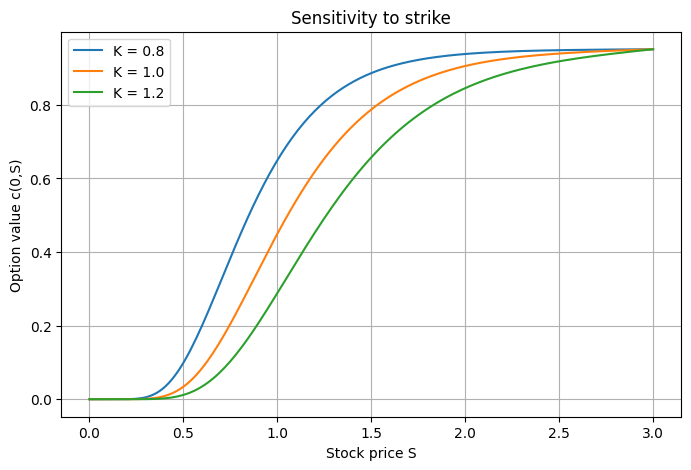

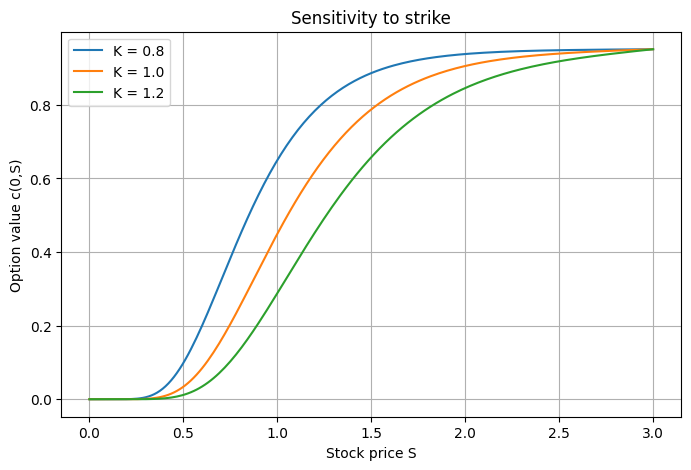

In [ ]:
Ks = [0.8, 1.0, 1.2]

plt.figure(figsize=(8,5))

for K_val in Ks:
    S, t, V = crank_nicolson_digital(K_val, r, sigma, T, S_max, M, N)
    plt.plot(S, V[:, 0], label=f"K = {K_val}")

plt.xlabel("Stock price S using Crank-Nicolson")
plt.ylabel("Option value c(0,S)")
plt.title("Sensitivity to strike")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))

for K_val in Ks:
    S, t, V = implicit_digital_call(K_val, r, sigma, T, S_max, M, N)
    plt.plot(S, V[:, 0], label=f"K = {K_val}")

plt.xlabel("Stock price S")
plt.ylabel("Option value c(0,S)")
plt.title("Sensitivity to strike using the implicit scheme")
plt.legend()
plt.grid(True)
plt.show()

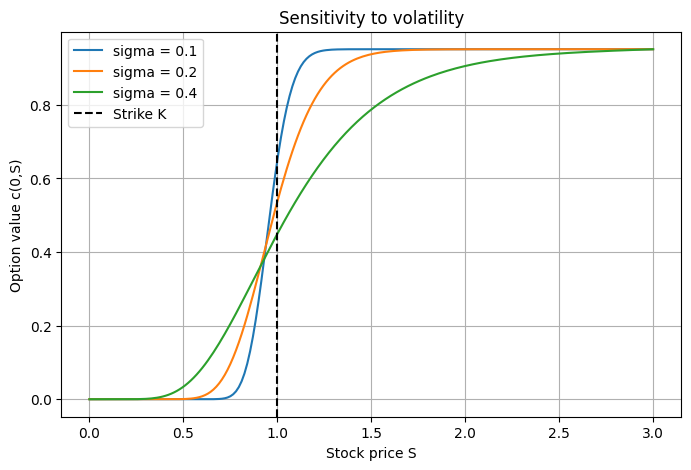

In [14]:
import matplotlib.pyplot as plt

sigmas = [0.1, 0.2, 0.4]

plt.figure(figsize=(8,5))

for sigma in sigmas:
    S, t, V = crank_nicolson_digital(K, r, sigma, T, S_max, M, N)
    plt.plot(S, V[:, 0], label=f"sigma = {sigma}")

plt.axvline(K, linestyle="--", color="black", label="Strike K")
plt.xlabel("Stock price S using Crank-Nicolson")
plt.ylabel("Option value c(0,S)")
plt.title("Sensitivity to volatility")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))

for sigma in sigmas:
    S, t, V = implicit_digital_call(K, r, sigma, T, S_max, M, N)
    plt.plot(S, V[:, 0], label=f"sigma = {sigma}")

plt.axvline(K, linestyle="--", color="black", label="Strike K")
plt.xlabel("Stock price S")
plt.ylabel("Option value c(0,S)")
plt.title("Sensitivity to volatility using the implicit scheme")
plt.legend()
plt.grid(True)
plt.show()